# Preparación de Datos para LSTM (Predicción de Precio BTC)
Este notebook carga el dataset fusionado (`df_merged.csv`), lo remuestrea a frecuencia semanal (o cada 5 días) y prepara las secuencias de entrada para un modelo LSTM.

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch
import torch.nn as nn

pd.set_option('display.max_columns', None)

print("✅ Librerías importadas")

✅ Librerías importadas


## 1. Configuración — Ruta del Archivo
Introduce aquí la ruta a tu archivo `df_merged.csv`.

In [125]:
# ✏️  EDITA ESTA RUTA con la ubicación de tu df_merged.csv
RUTA_CSV = "../data/csv/df_merged.csv"

df_raw = pd.read_csv(RUTA_CSV, parse_dates=["date"], index_col="date")
df_raw.sort_index(inplace=True)

print(f"✅ Archivo cargado: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas")
print(f"   Rango de fechas: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
display(df_raw.head(3))

✅ Archivo cargado: 2885 filas, 19 columnas
   Rango de fechas: 2018-02-01 → 2025-12-25


,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate
date,,,,,,,,,,,,,,,,,,,
2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,1119.369995,1161.349976,984.818970,1036.790039,5261680128,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42
2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,1035.770020,1035.770020,757.979980,915.784973,6713290240,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42
2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,919.210999,991.942993,847.690002,964.018982,3243480064,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42


## 2. Inspección de Columnas

In [126]:
print("Columnas disponibles:")
print(df_raw.columns.tolist())
print(f"\nValores nulos por columna:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}")
print(f"\nTipos de datos:\n{df_raw.dtypes}")

Columnas disponibles:
['btc_open', 'btc_high', 'btc_low', 'btc_close', 'btc_volume', 'eth_open', 'eth_high', 'eth_low', 'eth_close', 'eth_volume', 'btc_dominance', 'eth_dominance', 'alt_dominance', 'fear_greed', 'FearGreed_Label', 'inflation', 'btc_mcap', 'eth_mcap', 'fed_rate']

Valores nulos por columna:
FearGreed_Label    4
dtype: int64

Tipos de datos:
btc_open           float64
btc_high           float64
btc_low            float64
btc_close          float64
btc_volume           int64
eth_open           float64
eth_high           float64
eth_low            float64
eth_close          float64
eth_volume           int64
btc_dominance      float64
eth_dominance      float64
alt_dominance      float64
fear_greed         float64
FearGreed_Label     object
inflation          float64
btc_mcap           float64
eth_mcap           float64
fed_rate           float64
dtype: object


## 2b. Indicadores Técnicos (datos diarios)
Se calculan sobre los datos **diarios** antes del remuestreo para aprovechar toda la resolución temporal en los rolling windows.

| Categoría | Variable | Ventana |
|---|---|---|
| Sobrecompra/Sobreventa | `rsi_14`, `stoch_k` | 14 d |
| Volatilidad | `atr_pct`, `bb_width` | 14 / 20 d |
| Tendencia | `macd_hist`, `adx_14` | 12-26-9 / 14 d |
| Volumen / MCap | `vol_ratio`, `mcap_pct5` | EMA-20 / 5 d |
| Sentiment | `fng_scaled`, `dom_zscore` | — / 60 d |

In [127]:
import pandas as pd
import numpy as np


def add_core_indicators(df: pd.DataFrame) -> tuple:
    df = df.copy()

    open_  = df["eth_open"]
    high   = df["eth_high"]
    low    = df["eth_low"]
    close  = df["eth_close"]
    volume = df["eth_volume"]

    # ── 1. RSI(14) ──────────────────────────────────────────────────────────
    delta     = close.diff()
    gain      = delta.clip(lower=0)
    loss      = -delta.clip(upper=0)
    avg_gain  = gain.ewm(com=13, min_periods=14, adjust=False).mean()
    avg_loss  = loss.ewm(com=13, min_periods=14, adjust=False).mean()
    rs        = avg_gain / avg_loss
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # ── 2. Stochastic %K(14, smooth 3) ──────────────────────────────────────
    low_14    = low.rolling(14).min()
    high_14   = high.rolling(14).max()
    raw_k     = (close - low_14) / (high_14 - low_14) * 100
    df["stoch_k"] = raw_k.rolling(3).mean()          # smooth_k=3

    # ── 3. ATR relativo (ATR / close * 100) ─────────────────────────────────
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    atr = tr.ewm(com=13, min_periods=14, adjust=False).mean()
    df["atr_pct"] = atr / close * 100

    # ── 4. Bollinger Band Width ──────────────────────────────────────────────
    sma20     = close.rolling(20).mean()
    std20     = close.rolling(20).std(ddof=0)
    bb_upper  = sma20 + 2 * std20
    bb_lower  = sma20 - 2 * std20
    df["bb_width"] = (bb_upper - bb_lower) / sma20

    # ── 5. MACD Histogram normalizado ────────────────────────────────────────
    ema12       = close.ewm(span=12, adjust=False).mean()
    ema26       = close.ewm(span=26, adjust=False).mean()
    macd_line   = ema12 - ema26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df["macd_hist"] = (macd_line - signal_line) / close * 100

    # ── 6. ADX(14) ───────────────────────────────────────────────────────────
    up_move   = high.diff()
    down_move = -low.diff()
    plus_dm   = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm  = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    plus_dm_s  = pd.Series(plus_dm,  index=close.index).ewm(com=13, min_periods=14, adjust=False).mean()
    minus_dm_s = pd.Series(minus_dm, index=close.index).ewm(com=13, min_periods=14, adjust=False).mean()

    plus_di  = 100 * plus_dm_s  / atr
    minus_di = 100 * minus_dm_s / atr
    denom    = (plus_di + minus_di).replace(0, np.nan)   # evita división por cero
    dx       = 100 * (plus_di - minus_di).abs() / denom
    df["adx_14"] = dx.ewm(com=13, min_periods=14, adjust=False).mean()

    # ── 7. Volumen relativo (vol / EMA_vol_20) ────────────────────────────────
    ema_vol       = volume.ewm(span=20, adjust=False).mean()
    df["vol_ratio"] = volume / ema_vol

    # ── 8. Momentum de Market Cap a 5 días (%) ───────────────────────────────
    df["mcap_pct5_btc"] = df["btc_mcap"].pct_change(5) * 100
    df["mcap_pct5_eth"] = df["eth_mcap"].pct_change(5) * 100

    # ── 9. Fear & Greed escalado [0, 1] ──────────────────────────────────────
    df["fng_scaled"] = df["fear_greed"] / 100.0

    # ── 10. BTC Dominance z-score (ventana 60 días) ───────────────────────────
    dom           = df["btc_dominance"]
    dom_mean      = dom.rolling(60).mean()
    dom_std       = dom.rolling(60).std(ddof=1)
    df["dom_zscore"] = (dom - dom_mean) / dom_std

    INDICATOR_COLS = [
        "rsi_14", "stoch_k", "atr_pct", "bb_width",
        "macd_hist", "adx_14",
        "vol_ratio", "mcap_pct5_eth", "mcap_pct5_btc",
        "fng_scaled", "dom_zscore",
    ]
    return df, INDICATOR_COLS


df_raw, INDICATOR_COLS = add_core_indicators(df_raw)
print(f"\nNuevas columnas: {INDICATOR_COLS}")
display(df_raw[INDICATOR_COLS].dropna().head(30))


Nuevas columnas: ['rsi_14', 'stoch_k', 'atr_pct', 'bb_width', 'macd_hist', 'adx_14', 'vol_ratio', 'mcap_pct5_eth', 'mcap_pct5_btc', 'fng_scaled', 'dom_zscore']


,rsi_14,stoch_k,atr_pct,bb_width,macd_hist,adx_14,vol_ratio,mcap_pct5_eth,mcap_pct5_btc,fng_scaled,dom_zscore
date,,,,,,,,,,,
2018-04-01,16.239215,10.134895,12.488039,0.645237,-1.652097,61.197813,0.758983,-18.733535,-14.746207,0.16,1.254482
2018-04-02,18.116331,9.869107,11.716358,0.622359,-1.087840,62.080238,0.687483,-15.485163,-12.714987,0.11,1.551764
2018-04-03,26.087810,13.508887,10.691509,0.616283,0.015769,61.957465,0.862651,-13.227710,-10.672447,0.22,1.496934
2018-04-04,23.187523,13.786246,11.667538,0.619752,0.322429,61.921327,0.829404,7.998270,4.794673,0.22,1.238709
2018-04-05,23.861858,14.013385,11.091751,0.613083,0.748314,61.941205,0.796483,-3.706004,-0.698115,0.17,1.317027
2018-04-06,22.822945,7.366008,11.012305,0.629877,1.004293,61.989173,0.659073,-2.762508,-1.661288,0.19,1.168881
2018-04-07,26.806694,8.923951,10.255511,0.636250,1.507069,61.675044,0.670884,-2.328023,-2.985529,0.20,1.224958
2018-04-08,30.701235,12.882996,9.469812,0.618632,2.136898,60.947245,0.690562,-0.255398,-2.711223,0.17,1.216164
2018-04-09,30.473452,20.759852,9.529700,0.590720,2.626132,59.140554,1.068594,-4.407783,-6.370478,0.21,1.124420


| #  | Indicador   | Categoría               | Señal clave                         |
| -- | ----------- | ----------------------- | ----------------------------------- |
| 1  | RSI 14      | Sobrecompra/sobreventa  | >70 caliente, <30 frío              |
| 2  | Stoch %K    | Sobrecompra/sobreventa  | >80 sobrecompra, <20 sobreventa     |
| 3  | ATR%        | Volatilidad absoluta    | Alto = mercado nervioso             |
| 4  | BB Width    | Volatilidad estadística | Estrecho = compresión previa        |
| 5  | MACD Hist   | Momentum/tendencia      | Positivo = impulso alcista          |
| 6  | ADX 14      | Fuerza de tendencia     | >25 = tendencia real                |
| 7  | Vol Ratio   | Volumen relativo        | >1.5 = movimiento significativo     |
| 8  | MCap Pct5   | Flujo de capital        | Positivo = entra dinero             |
| 9  | FNG Scaled  | Sentimiento externo     | >0.75 = euforia, <0.25 = miedo      |
| 10 | Dom Z-Score | Estado del ecosistema   | Alto = BTC domina, bajo = altseason |

## 2c. Vista del DataFrame enriquecido y correlación con `eth_close`

In [128]:
TARGET = "eth_close"

PRICE_COLS = [c for c in df_raw.columns]

all_feature_cols = PRICE_COLS + INDICATOR_COLS
df_enriched = df_raw[all_feature_cols].dropna()

print(f"DataFrame enriquecido: {df_enriched.shape[0]} filas × {df_enriched.shape[1]} columnas")
display(df_enriched.head(5))

DataFrame enriquecido: 2822 filas × 41 columnas


,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate,rsi_14,stoch_k,atr_pct,bb_width,macd_hist,adx_14,vol_ratio,mcap_pct5_btc,mcap_pct5_eth,fng_scaled,dom_zscore,rsi_14,stoch_k,atr_pct,bb_width,macd_hist,adx_14,vol_ratio,mcap_pct5_eth,mcap_pct5_btc,fng_scaled,dom_zscore
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-04-01,7003.060059,7060.950195,6526.870117,6844.229980,4532100096,397.253998,400.528015,363.804993,379.606995,1256930048,0.440438,0.145284,0.414278,16.0,Extreme Fear,2.470996,1.182341e+11,3.900087e+10,1.69,16.239215,10.134895,12.488039,0.645237,-1.652097,61.197813,0.758983,-14.746207,-18.733535,0.16,1.254482,16.239215,10.134895,12.488039,0.645237,-1.652097,61.197813,0.758983,-18.733535,-14.746207,0.16,1.254482
2018-04-02,6844.859863,7135.470215,6816.580078,7083.799805,4333440000,379.699005,395.170990,377.592987,386.424988,1102259968,0.452665,0.145941,0.401393,11.0,Extreme Fear,2.470996,1.158969e+11,3.736564e+10,1.69,18.116331,9.869107,11.716358,0.622359,-1.087840,62.080238,0.687483,-12.714987,-15.485163,0.11,1.551764,18.116331,9.869107,11.716358,0.622359,-1.087840,62.080238,0.687483,-15.485163,-12.714987,0.11,1.551764
2018-04-03,7102.259766,7530.939941,7072.490234,7456.109863,5499700224,387.312012,418.967987,383.532013,416.893005,1363399936,0.452381,0.142958,0.404661,22.0,Extreme Fear,2.470996,1.200442e+11,3.793555e+10,1.69,26.087810,13.508887,10.691509,0.616283,0.015769,61.957465,0.862651,-10.672447,-13.227710,0.22,1.496934,26.087810,13.508887,10.691509,0.616283,0.015769,61.957465,0.862651,-13.227710,-10.672447,0.22,1.496934
2018-04-04,7456.410156,7469.879883,6803.879883,6853.839844,4936000000,416.484985,417.471985,375.309998,380.542999,1287730048,0.444703,0.144016,0.411281,22.0,Extreme Fear,2.470996,1.265689e+11,4.098913e+10,1.69,23.187523,13.786246,11.667538,0.619752,0.322429,61.921327,0.829404,4.794673,7.998270,0.22,1.238709,23.187523,13.786246,11.667538,0.619752,0.322429,61.921327,0.829404,7.998270,4.794673,0.22,1.238709
2018-04-05,6848.649902,6933.819824,6644.799805,6811.470215,5639320064,379.946991,387.716003,369.816010,383.231995,1210680064,0.448740,0.144973,0.406287,17.0,Extreme Fear,2.470996,1.160848e+11,3.750310e+10,1.69,23.861858,14.013385,11.091751,0.613083,0.748314,61.941205,0.796483,-0.698115,-3.706004,0.17,1.317027,23.861858,14.013385,11.091751,0.613083,0.748314,61.941205,0.796483,-3.706004,-0.698115,0.17,1.317027


## 2d. One-Hot Encoding de `FearGreed_Label`
Convierte la etiqueta categorica en columnas binarias (0/1).  
Al remuestrear a semanal, estas columnas se sumaran -> **numero de dias** de cada regimen de sentimiento en esa semana.

In [129]:
# One-Hot Encoding de FearGreed_Label
ohe = pd.get_dummies(df_raw['FearGreed_Label'], prefix='fng', dtype=int)

# Renombrar espacios por guion bajo para facilitar el acceso
ohe.columns = [c.replace(' ', '_') for c in ohe.columns]

# Unir al dataframe principal (sustituye FearGreed_Label por las columnas OHE)
df_raw = df_raw.drop(columns=['FearGreed_Label']).join(ohe)

OHE_COLS = ohe.columns.tolist()
print(f'Columnas OHE creadas: {OHE_COLS}')
print(f'Distribucion total de dias por sentimiento:')
print(df_raw[OHE_COLS].sum().sort_values(ascending=False).to_string())
display(df_raw[OHE_COLS].head(10))

Columnas OHE creadas: ['fng_Extreme_Fear', 'fng_Extreme_Greed', 'fng_Fear', 'fng_Greed', 'fng_Neutral']
Distribucion total de dias por sentimiento:
fng_Fear             827
fng_Greed            789
fng_Extreme_Fear     596
fng_Neutral          388
fng_Extreme_Greed    281


,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral
date,,,,,
2018-02-01,0,0,1,0,0
2018-02-02,1,0,0,0,0
2018-02-03,0,0,1,0,0
2018-02-04,1,0,0,0,0
2018-02-05,1,0,0,0,0
2018-02-06,1,0,0,0,0
2018-02-07,0,0,1,0,0
2018-02-08,0,0,1,0,0
2018-02-09,0,0,1,0,0


## 3. Remuestreo — Semanal o cada 5 días
Elige la frecuencia de remuestreo:  
- `'W-MON'` → semanal (cada lunes)  
- `'5D'`   → cada 5 días

In [130]:
# ✏️  Frecuencia: 'W-MON' (semanal, ancla lunes) o '5D' (cada 5 días)
FRECUENCIA = '3D'

# ── Reglas por tipo de columna ────────────────────────────────────────────────

# OHLCV: preservar sentido de vela/semana
ohlcv_rules = {
    'btc_open':   'first', 'btc_high':   'max', 'btc_low':   'min',
    'btc_close':  'last',  'btc_volume': 'sum',
    'eth_open':   'first', 'eth_high':   'max', 'eth_low':   'min',
    'eth_close':  'last',  'eth_volume': 'sum',
}

# OHE: sumar → número de días de cada régimen de sentimiento en la semana
ohe_rules = {col: 'sum' for col in OHE_COLS if col in df_raw.columns}

# Indicadores técnicos: último valor de la semana (el más reciente)
indicator_rules = {col: 'last' for col in INDICATOR_COLS if col in df_raw.columns}

# Resto de columnas numéricas: media del período
already_assigned = set(ohlcv_rules) | set(ohe_rules) | set(indicator_rules)
otras_cols = [
    c for c in df_raw.select_dtypes(include='number').columns
    if c not in already_assigned
]
otras_rules = {c: 'mean' for c in otras_cols}

# Unir todas las reglas y filtrar solo columnas presentes
agg_rules = {**ohlcv_rules, **ohe_rules, **indicator_rules, **otras_rules}
agg_rules  = {k: v for k, v in agg_rules.items() if k in df_raw.columns}

df_weekly = df_raw.resample(FRECUENCIA).agg(agg_rules)
df_weekly.dropna(inplace=True)

print(f'✅ Remuestreo "{FRECUENCIA}" completado: {df_weekly.shape[0]} semanas x {df_weekly.shape[1]} columnas')
print(f'Conteo semanal de días por sentimiento (primeras 5 semanas):')
display(df_weekly[OHE_COLS].head())
display(df_weekly.head(3))

✅ Remuestreo "3D" completado: 943 semanas x 34 columnas
Conteo semanal de días por sentimiento (primeras 5 semanas):


,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral
date,,,,,
2018-03-30,3,0,0,0,0
2018-04-02,3,0,0,0,0
2018-04-05,3,0,0,0,0
2018-04-08,3,0,0,0,0
2018-04-11,3,0,0,0,0


,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral,rsi_14,stoch_k,atr_pct,bb_width,macd_hist,adx_14,vol_ratio,mcap_pct5_eth,mcap_pct5_btc,fng_scaled,dom_zscore,btc_dominance,eth_dominance,alt_dominance,fear_greed,inflation,btc_mcap,eth_mcap,fed_rate
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-30,7171.450195,7276.660156,6526.870117,6844.229980,15374879744,385.904999,418.467987,363.804993,379.606995,4458980096,3,0,0,0,0,16.239215,10.134895,12.488039,0.645237,-1.652097,61.197813,0.758983,-18.733535,-14.746207,0.16,1.254482,0.442002,0.143952,0.414047,14.666667,2.377632,1.186376e+11,3.863361e+10,1.57
2018-04-02,6844.859863,7530.939941,6803.879883,6853.839844,14769140224,379.699005,418.967987,375.309998,380.542999,3753389952,3,0,0,0,0,23.187523,13.786246,11.667538,0.619752,0.322429,61.921327,0.829404,7.998270,4.794673,0.22,1.238709,0.449916,0.144305,0.405778,18.333333,2.470996,1.208367e+11,3.876344e+10,1.69
2018-04-05,6848.649902,7050.540039,6575.000000,6911.089844,13382740224,379.946991,393.058990,366.911011,385.313995,3129261056,3,0,0,0,0,26.806694,8.923951,10.255511,0.636250,1.507069,61.675044,0.670884,-2.328023,-2.985529,0.20,1.224958,0.447256,0.145181,0.407563,18.666667,2.470996,1.149305e+11,3.730744e+10,1.69


Columnas eliminadas por redundancia (|corr| >= 0.97 con otra): ['btc_high', 'btc_low', 'btc_close', 'eth_high', 'eth_low', 'eth_close', 'fear_greed', 'btc_mcap', 'eth_mcap']

Features finales (16): ['btc_open', 'btc_volume', 'eth_open', 'eth_volume', 'fng_Extreme_Fear', 'fng_Fear', 'fng_Greed', 'rsi_14', 'bb_width', 'fng_scaled', 'btc_dominance', 'eth_dominance', 'alt_dominance', 'inflation', 'fed_rate', 'eth_close']


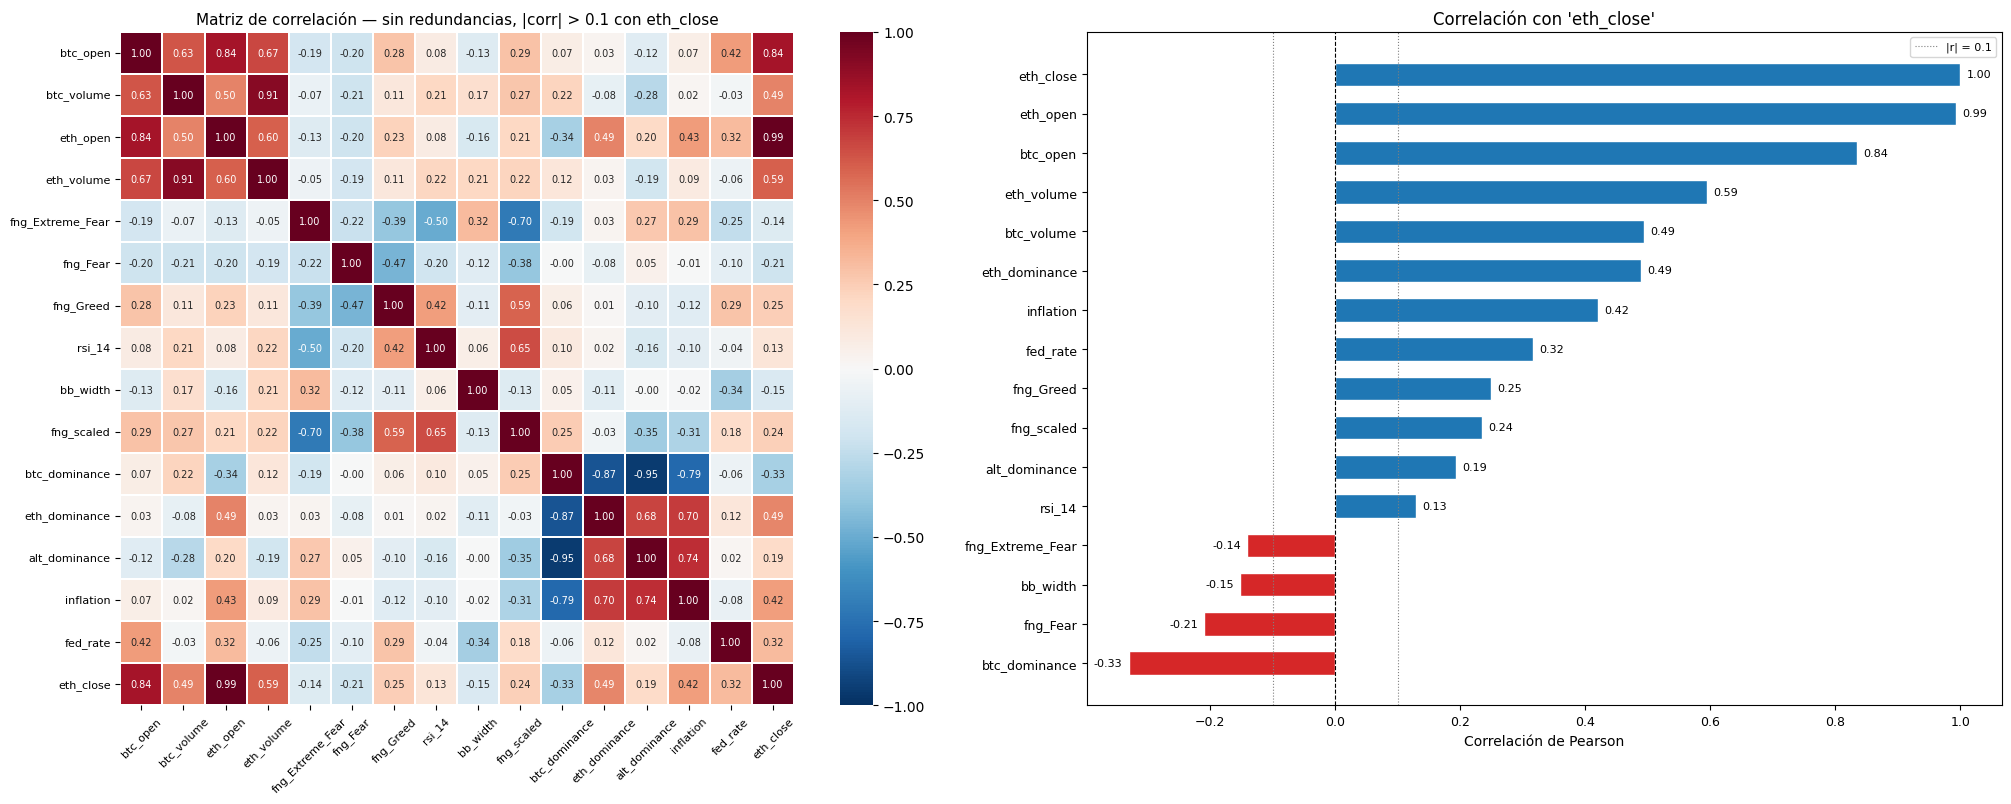


Correlaciones finales con eth_close:
btc_dominance      -0.330200
fng_Fear           -0.209000
bb_width           -0.151512
fng_Extreme_Fear   -0.140186
rsi_14              0.128996
alt_dominance       0.193587
fng_scaled          0.235072
fng_Greed           0.248923
fed_rate            0.317172
inflation           0.421104
eth_dominance       0.488739
btc_volume          0.493450
eth_volume          0.594597
btc_open            0.835052
eth_open            0.993730
eth_close           1.000000


In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

TARGET = "eth_close"

corr_matrix = df_weekly.corr(numeric_only=True)

# ── Paso 1: eliminar columnas que tengan |corr| >= 0.97 con CUALQUIER otra ───
# (detecta columnas casi idénticas/redundantes entre sí)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
cols_redundantes = [
    col for col in upper_tri.columns
    if (upper_tri[col].abs() >= 0.97).any()
]
print(f"Columnas eliminadas por redundancia (|corr| >= 0.97 con otra): {cols_redundantes}")

# ── Paso 2: quedarnos con las que NO son redundantes + siempre incluir TARGET ─
cols_limpias = [c for c in corr_matrix.columns if c not in cols_redundantes]
if TARGET not in cols_limpias:
    cols_limpias.append(TARGET)

# ── Paso 3: de las limpias, filtrar las que tengan |corr| > 0.1 con eth_close ─
corr_target    = corr_matrix.loc[cols_limpias, TARGET]
cols_relevantes = corr_target[corr_target.abs() > 0.1].index.tolist()

# Asegurar que TARGET está incluido
if TARGET not in cols_relevantes:
    cols_relevantes.append(TARGET)

corr_filtrada   = corr_matrix.loc[cols_relevantes, cols_relevantes]
corr_target_fil = corr_matrix.loc[cols_relevantes, TARGET].sort_values()

print(f"\nFeatures finales ({len(cols_relevantes)}): {cols_relevantes}")

# ── Plots ─────────────────────────────────────────────────────────────────────
n = len(cols_relevantes)
fig, axes = plt.subplots(1, 2, figsize=(max(20, n * 0.8 + 8), max(8, n * 0.5)))

sns.heatmap(
    corr_filtrada,
    ax=axes[0],
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    square=True,
    annot_kws={"size": 7},
)
axes[0].set_title("Matriz de correlación — sin redundancias, |corr| > 0.1 con eth_close", fontsize=11)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

colors = ["#d62728" if v < 0 else "#1f77b4" for v in corr_target_fil.values]
axes[1].barh(corr_target_fil.index, corr_target_fil.values, color=colors, edgecolor="white", height=0.6)
axes[1].axvline(0,    color="black", linewidth=0.8, linestyle="--")
axes[1].axvline(0.1,  color="gray",  linewidth=0.8, linestyle=":", label="|r| = 0.1")
axes[1].axvline(-0.1, color="gray",  linewidth=0.8, linestyle=":")
axes[1].set_xlabel("Correlación de Pearson")
axes[1].set_title(f"Correlación con '{TARGET}'", fontsize=12)
axes[1].tick_params(labelsize=9)
axes[1].legend(fontsize=8)
for i, v in enumerate(corr_target_fil.values):
    axes[1].text(
        v + (0.01 if v >= 0 else -0.01), i,
        f"{v:.2f}", va="center",
        ha="left" if v >= 0 else "right",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("../notebooks/corr_eth_close_weekly.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nCorrelaciones finales con {TARGET}:\n{corr_target_fil.to_string()}")


## 4. Preparación para LSTM
Selección de features, normalización y construcción de secuencias temporales.

In [132]:
# ✏️ Variable objetivo
TARGET_COL = 'eth_close'

# ✏️ Features de entrada — eth_close fuera, se usa solo como target
FEATURE_COLS = [
    'btc_volume', 'btc_close',
    'eth_volume',
    'rsi_14', 'macd_hist', 'bb_width', 'atr_pct', 'adx_14', 'stoch_k',
    'fng_scaled', 'fear_greed', 'btc_dominance', 'eth_dominance', 'alt_dominance',
    'inflation', 'fed_rate',
]
# Aseguramos que eth_close NO está entre las features
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_weekly.columns and c != TARGET_COL]

SEQ_LEN = 18

# ── Normalización independiente para features y target ───────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

data_X = scaler_X.fit_transform(df_weekly[FEATURE_COLS])           # shape (T, n_features)
data_y = scaler_y.fit_transform(df_weekly[[TARGET_COL]])           # shape (T, 1)

# ── Construcción de secuencias ────────────────────────────────────────────────
# X[i] = features de las semanas [i, i+SEQ_LEN)       → lo que el modelo ve
# y[i] = eth_close de la semana  i+SEQ_LEN             → lo que predice
X, y = [], []
for i in range(SEQ_LEN, len(data_X)):
    X.append(data_X[i - SEQ_LEN : i])     # SEQ_LEN semanas de historia
    y.append(data_y[i])                    # precio de la semana siguiente

X, y = np.array(X), np.array(y).squeeze()

# ── Split temporal 80/20 (sin shuffle, orden temporal obligatorio) ────────────
split   = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Ventana  : {SEQ_LEN} semanas")
print(f"X_train  : {X_train.shape}  →  (muestras, semanas, features)")
print(f"X_test   : {X_test.shape}")
print(f"y_train  : {y_train.shape}  →  eth_close semana siguiente (normalizado)")
print("Datos listos ✓")

Features (16): ['btc_volume', 'btc_close', 'eth_volume', 'rsi_14', 'macd_hist', 'bb_width', 'atr_pct', 'adx_14', 'stoch_k', 'fng_scaled', 'fear_greed', 'btc_dominance', 'eth_dominance', 'alt_dominance', 'inflation', 'fed_rate']
Ventana  : 18 semanas
X_train  : (740, 18, 16)  →  (muestras, semanas, features)
X_test   : (185, 18, 16)
y_train  : (740,)  →  eth_close semana siguiente (normalizado)
Datos listos ✓


In [133]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")


Dispositivo: cuda


In [142]:
# ✏️  Hiperparámetros
LAYER_SIZES = [64, 32]   # neuronas por capa LSTM
DROPOUT     = 0.2            # dropout entre capas intermedias
BATCH_SIZE  = 16
EPOCHS      = 5000
LR          = 1e-4
PATIENCE    = 300             # early stopping: epocas sin mejora en val_loss


In [143]:
class CryptoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(CryptoDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CryptoDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)


class StackedLSTM(nn.Module):
    """Tres capas LSTM con tamanos distintos (32 -> 64 -> 32) + salida escalar."""
    def __init__(self, n_features, layer_sizes, dropout):
        super().__init__()
        self.lstms = nn.ModuleList()
        in_size = n_features
        for out_size in layer_sizes:
            self.lstms.append(
                nn.LSTM(input_size=in_size, hidden_size=out_size,
                        num_layers=1, batch_first=True)
            )
            in_size = out_size
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(layer_sizes[-1], 1)

    def forward(self, x):
        for i, lstm in enumerate(self.lstms):
            x, _ = lstm(x)                      # (batch, seq_len, hidden_i)
            if i < len(self.lstms) - 1:
                x = self.dropout(x)             # dropout entre capas
        return self.fc(x[:, -1])                # ultimo paso temporal -> escalar


n_features = X_train.shape[2]
model      = StackedLSTM(n_features, LAYER_SIZES, DROPOUT).to(DEVICE)
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LR)

arch_str = " -> ".join(str(s) for s in LAYER_SIZES)
print(f"Arquitectura  : LSTM  {n_features} -> {arch_str} -> 1")
print(f"Parametros    : {sum(p.numel() for p in model.parameters()):,}")


Arquitectura  : LSTM  16 -> 64 -> 32 -> 1
Parametros    : 33,569


In [144]:
# ── Función auxiliar ──────────────────────────────────────────────────────────
def dir_acc(real, pred):
    real, pred = np.array(real).squeeze(), np.array(pred).squeeze()
    return np.mean(np.sign(np.diff(real)) == np.sign(np.diff(pred))) * 100

# ── Entrenamiento ─────────────────────────────────────────────────────────────
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []          # ← NUEVO
best_val_loss     = float('inf')
epochs_no_improve = 0
best_state        = None

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    loss_sum      = 0.0
    train_preds   = []                      # ← NUEVO
    train_labels  = []                      # ← NUEVO

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * len(y_b)
        train_preds.append(out.detach().cpu().numpy())       # ← NUEVO
        train_labels.append(y_b.detach().cpu().numpy())     # ← NUEVO

    train_losses.append(loss_sum / len(X_train))
    train_accs.append(                                       # ← NUEVO
        dir_acc(np.concatenate(train_labels),
                np.concatenate(train_preds))
    )

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        loss_sum    = 0.0
        test_preds  = []                    # ← NUEVO
        test_labels = []                    # ← NUEVO

        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE).unsqueeze(1)
            out       = model(X_b)
            loss_sum += criterion(out, y_b).item() * len(y_b)
            test_preds.append(out.cpu().numpy())             # ← NUEVO
            test_labels.append(y_b.cpu().numpy())           # ← NUEVO

    val_loss = loss_sum / len(X_test)
    test_losses.append(val_loss)
    test_accs.append(                                        # ← NUEVO
        dir_acc(np.concatenate(test_labels),
                np.concatenate(test_preds))
    )

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        best_state        = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping en época {epoch} (sin mejora durante {PATIENCE} épocas)")
            break

    if epoch % 20 == 0:
        print(f"Época {epoch:4d}/{EPOCHS} | "
              f"train={train_losses[-1]:.5f}  val={val_loss:.5f} | "
              f"train_acc={train_accs[-1]:.1f}%  val_acc={test_accs[-1]:.1f}%")  # ← NUEVO

model.load_state_dict(best_state)
best_epoch = len(train_losses) - epochs_no_improve
print(f"\nMejor val_loss : {best_val_loss:.6f}  (época {best_epoch})")
print(f"Train acc final: {train_accs[best_epoch-1]:.1f}%")
print(f"Val   acc final: {test_accs[best_epoch-1]:.1f}%")

Época   20/5000 | train=0.00905  val=0.04588 | train_acc=48.8%  val_acc=53.3%
Época   40/5000 | train=0.00439  val=0.01441 | train_acc=49.1%  val_acc=53.3%
Época   60/5000 | train=0.00508  val=0.01330 | train_acc=49.4%  val_acc=51.1%
Época   80/5000 | train=0.00416  val=0.01097 | train_acc=51.4%  val_acc=50.5%
Época  100/5000 | train=0.00581  val=0.01624 | train_acc=47.0%  val_acc=51.1%
Época  120/5000 | train=0.00521  val=0.01087 | train_acc=48.7%  val_acc=51.6%
Época  140/5000 | train=0.00395  val=0.02589 | train_acc=51.6%  val_acc=52.2%
Época  160/5000 | train=0.00370  val=0.01257 | train_acc=52.2%  val_acc=50.5%
Época  180/5000 | train=0.00287  val=0.01029 | train_acc=50.6%  val_acc=49.5%
Época  200/5000 | train=0.00478  val=0.01118 | train_acc=50.5%  val_acc=50.5%
Época  220/5000 | train=0.00403  val=0.01226 | train_acc=52.8%  val_acc=50.5%
Época  240/5000 | train=0.00431  val=0.01123 | train_acc=48.8%  val_acc=51.1%
Época  260/5000 | train=0.00203  val=0.01286 | train_acc=50.7%  


── TRAIN ───────────────────────────────────
  MAE  :     226.59 $
  RMSE :     324.40 $
  MAPE :      30.16 %
  R²   :     0.9299
  Dir.Accuracy : 53.7 %

── TEST ───────────────────────────────────
  MAE  :     388.95 $
  RMSE :     470.78 $
  MAPE :      13.44 %
  R²   :     0.6249
  Dir.Accuracy : 51.1 %


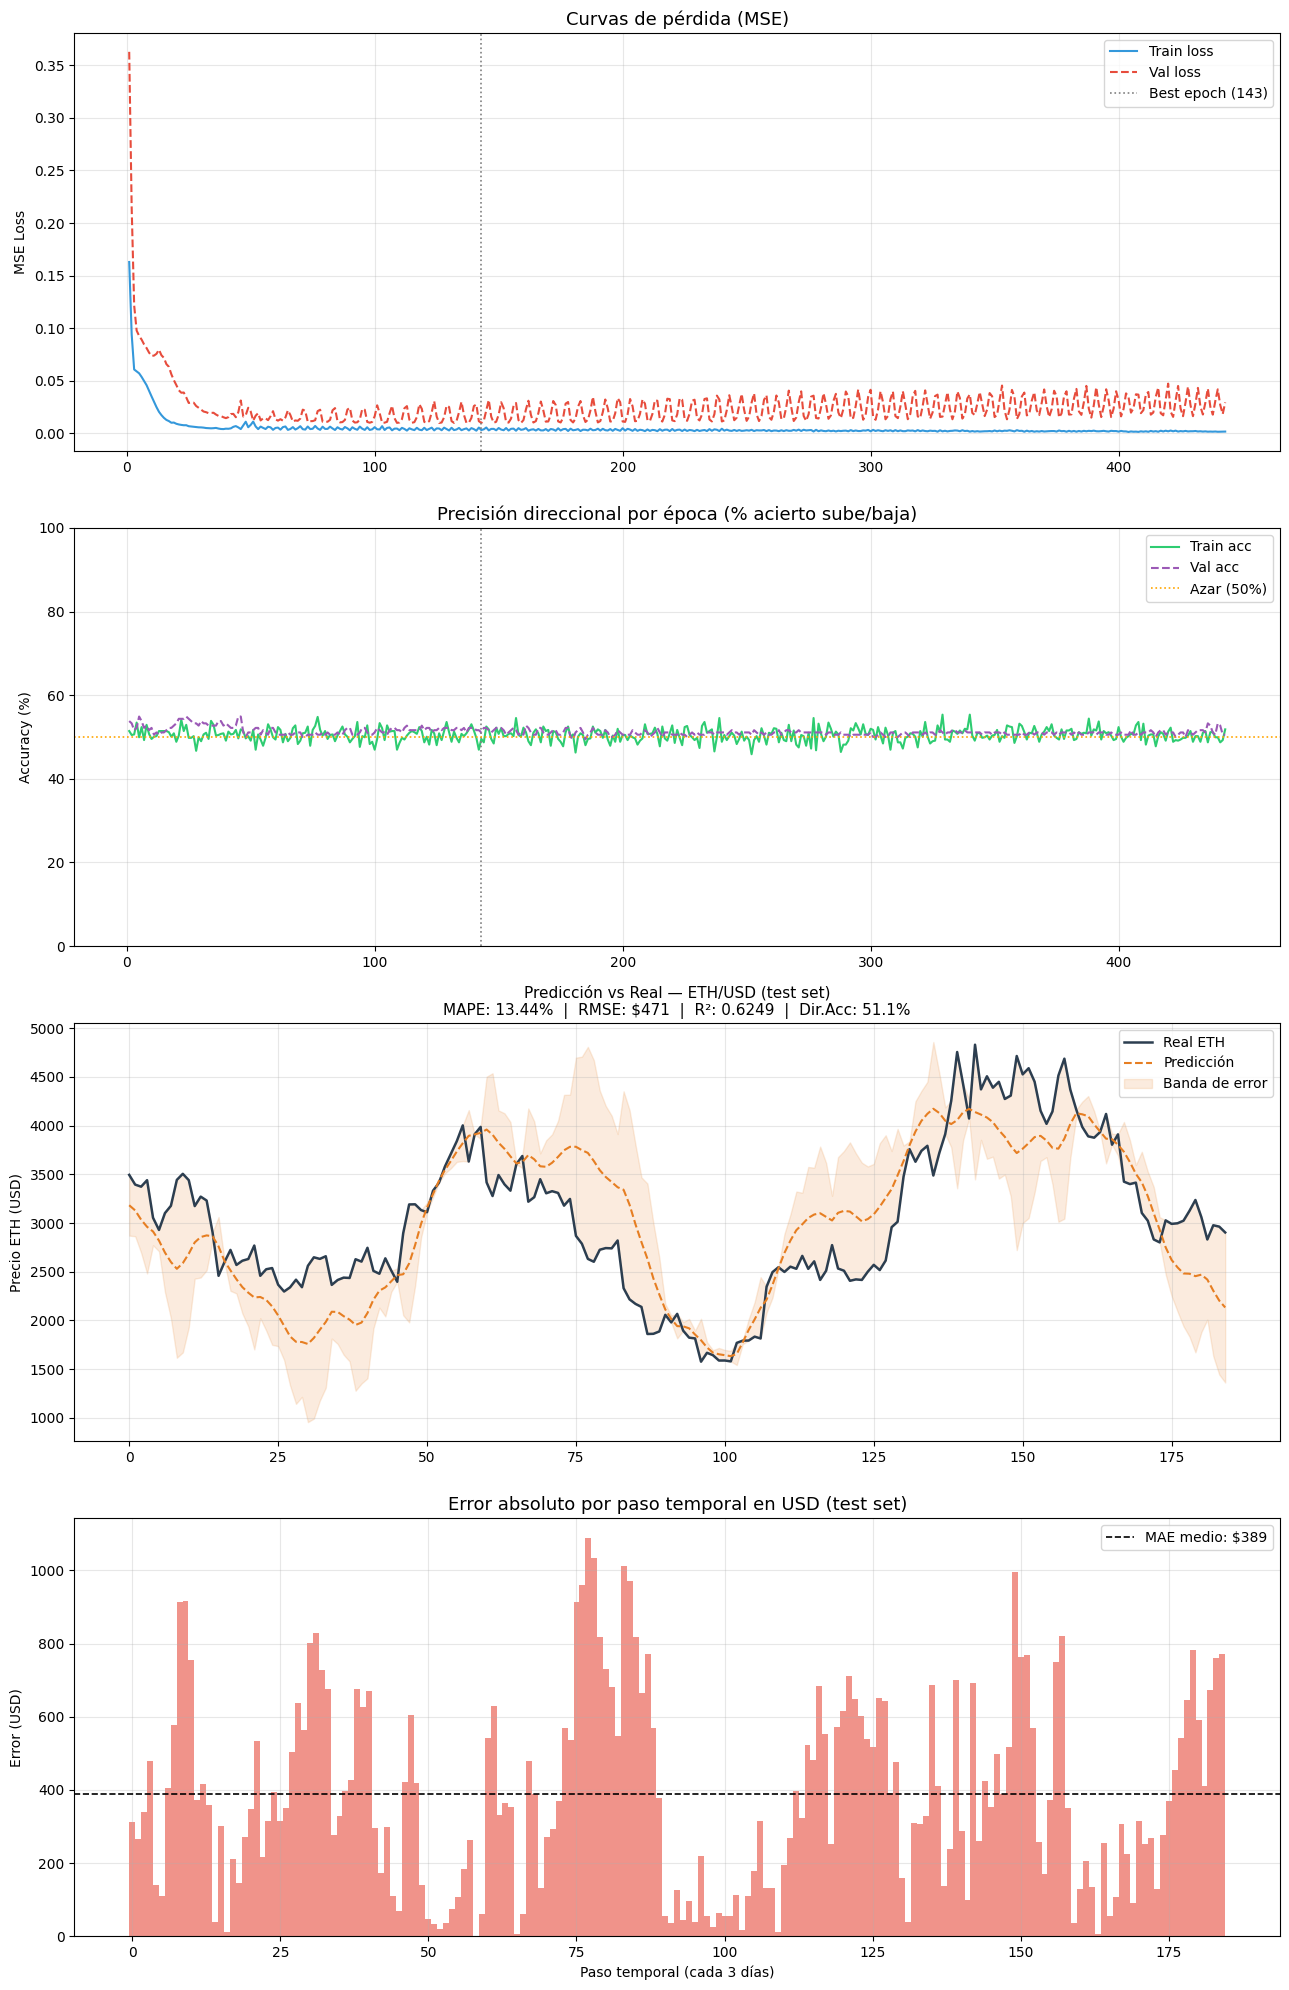


── Contexto para RAG ──────────────────────────────────────────────────
  activo: ETH/USD
  precio_actual_usd: 2903.58
  precio_predicho_3d: 2133.36
  variacion_pct: -26.53
  direccion: BAJADA
  metricas_modelo: {'mape': np.float64(13.44), 'rmse': np.float64(470.78), 'r2': np.float64(0.6249), 'dir_accuracy': np.float64(51.1)}
  mercado_actual: {'rsi_14': 41.92, 'fear_greed': 23.5, 'adx_14': 30.5, 'bb_width': 0.1765}


In [145]:
import matplotlib.pyplot as plt

# ── Predicciones desescaladas ─────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    p_train = model(torch.FloatTensor(X_train).to(DEVICE)).cpu().numpy()
    p_test  = model(torch.FloatTensor(X_test).to(DEVICE)).cpu().numpy()

preds_train = scaler_y.inverse_transform(p_train.reshape(-1,1)).squeeze()
preds_test  = scaler_y.inverse_transform(p_test.reshape(-1,1)).squeeze()
real_train  = scaler_y.inverse_transform(y_train.reshape(-1,1)).squeeze()
real_test   = scaler_y.inverse_transform(y_test.reshape(-1,1)).squeeze()

# ── Métricas ──────────────────────────────────────────────────────────────────
def metrics(real, preds, label):
    mae  = np.mean(np.abs(preds - real))
    rmse = np.sqrt(np.mean((preds - real)**2))
    mape = np.mean(np.abs((preds - real) / real)) * 100
    r2   = 1 - np.sum((real-preds)**2) / np.sum((real-np.mean(real))**2)
    da   = dir_acc(real, preds)
    print(f"\n── {label} ───────────────────────────────────")
    print(f"  MAE  : {mae:>10,.2f} $")
    print(f"  RMSE : {rmse:>10,.2f} $")
    print(f"  MAPE : {mape:>10.2f} %")
    print(f"  R²   : {r2:>10.4f}")
    print(f"  Dir.Accuracy : {da:.1f} %")
    return mae, rmse, mape, r2, da

mae_tr, rmse_tr, mape_tr, r2_tr, da_tr = metrics(real_train, preds_train, "TRAIN")
mae_te, rmse_te, mape_te, r2_te, da_te = metrics(real_test,  preds_test,  "TEST")

# ── 4 paneles ─────────────────────────────────────────────────────────────────
epochs_x  = range(1, len(train_losses) + 1)
error_abs = np.abs(preds_test - real_test)

fig, axes = plt.subplots(4, 1, figsize=(13, 20))

# Panel 1 — Pérdida
axes[0].plot(epochs_x, train_losses, label='Train loss', color='#3498db', linewidth=1.5)
axes[0].plot(epochs_x, test_losses,  label='Val loss',   color='#e74c3c', linewidth=1.5, linestyle='--')
axes[0].axvline(best_epoch, color='gray', linestyle=':', linewidth=1.2, label=f'Best epoch ({best_epoch})')
axes[0].set_title('Curvas de pérdida (MSE)', fontsize=13)
axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2 — Directional Accuracy
axes[1].plot(epochs_x, train_accs, label='Train acc', color='#2ecc71', linewidth=1.5)
axes[1].plot(epochs_x, test_accs,  label='Val acc',   color='#9b59b6', linewidth=1.5, linestyle='--')
axes[1].axvline(best_epoch, color='gray', linestyle=':', linewidth=1.2)
axes[1].axhline(50, color='orange', linestyle=':', linewidth=1.2, label='Azar (50%)')
axes[1].set_title('Precisión direccional por época (% acierto sube/baja)', fontsize=13)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(); axes[1].grid(alpha=0.3)

# Panel 3 — Predicción vs Real en USD
axes[2].plot(real_test,  label='Real ETH',    color='#2c3e50', linewidth=1.8)
axes[2].plot(preds_test, label='Predicción',  color='#e67e22', linewidth=1.5, linestyle='--')
axes[2].fill_between(range(len(real_test)),
                     preds_test - error_abs,
                     preds_test + error_abs,
                     alpha=0.15, color='#e67e22', label='Banda de error')
axes[2].set_title(
    f'Predicción vs Real — ETH/USD (test set)\n'
    f'MAPE: {mape_te:.2f}%  |  RMSE: ${rmse_te:,.0f}  |  R²: {r2_te:.4f}  |  Dir.Acc: {da_te:.1f}%',
    fontsize=11)
axes[2].set_ylabel('Precio ETH (USD)')
axes[2].legend(); axes[2].grid(alpha=0.3)

# Panel 4 — Error absoluto por paso
axes[3].bar(range(len(error_abs)), error_abs, color='#e74c3c', alpha=0.6, width=1.0)
axes[3].axhline(np.mean(error_abs), color='black', linewidth=1.2,
                linestyle='--', label=f'MAE medio: ${np.mean(error_abs):,.0f}')
axes[3].set_title('Error absoluto por paso temporal en USD (test set)', fontsize=13)
axes[3].set_xlabel('Paso temporal (cada 3 días)')
axes[3].set_ylabel('Error (USD)')
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/lstm_resultado_completo.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Contexto RAG ──────────────────────────────────────────────────────────────
rag_context = {
    "activo"             : "ETH/USD",
    "precio_actual_usd"  : round(float(real_test[-1]), 2),
    "precio_predicho_3d" : round(float(preds_test[-1]), 2),
    "variacion_pct"      : round((float(preds_test[-1]) - float(real_test[-1])) / float(real_test[-1]) * 100, 2),
    "direccion"          : "SUBIDA" if preds_test[-1] > real_test[-1] else "BAJADA",
    "metricas_modelo"    : {"mape": round(mape_te,2), "rmse": round(rmse_te,2),
                            "r2": round(r2_te,4), "dir_accuracy": round(da_te,1)},
    "mercado_actual"     : {
        "rsi_14"     : round(float(df_weekly["rsi_14"].iloc[-1]),    2),
        "fear_greed" : round(float(df_weekly["fear_greed"].iloc[-1]),2),
        "adx_14"     : round(float(df_weekly["adx_14"].iloc[-1]),    2),
        "bb_width"   : round(float(df_weekly["bb_width"].iloc[-1]),  4),
    }
}
print("\n── Contexto para RAG ──────────────────────────────────────────────────")
for k, v in rag_context.items():
    print(f"  {k}: {v}")

MAE  : 21,255.57 $
RMSE : 24,772.82 $
MAPE : 21.79 %


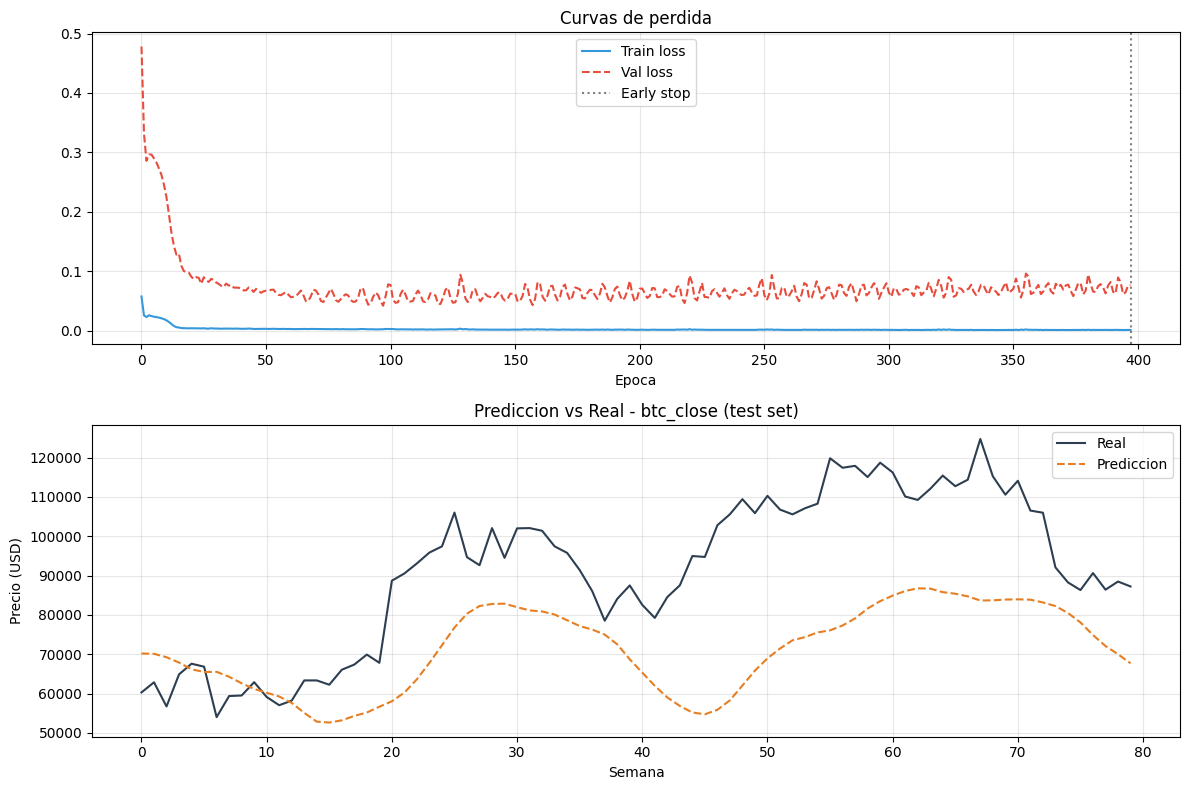

In [ ]:
# Predicciones en escala original
model.eval()
with torch.no_grad():
    preds_scaled = model(torch.FloatTensor(X_test).to(DEVICE)).cpu().numpy()
preds = scaler_target.inverse_transform(preds_scaled)
real  = scaler_target.inverse_transform(y_test.reshape(-1, 1))

mae  = np.mean(np.abs(preds - real))
rmse = np.sqrt(np.mean((preds - real) ** 2))
mape = np.mean(np.abs((preds - real) / real)) * 100
print(f"MAE  : {mae:,.2f} $")
print(f"RMSE : {rmse:,.2f} $")
print(f"MAPE : {mape:.2f} %")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(train_losses, label='Train loss', color='#3498db')
ax1.plot(test_losses,  label='Val loss',   color='#e74c3c', linestyle='--')
ax1.axvline(len(train_losses) - 1, color='gray', linestyle=':', label='Early stop')
ax1.set_title('Curvas de perdida'); ax1.set_xlabel('Epoca')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(real,  label='Real',       color='#2c3e50', linewidth=1.5)
ax2.plot(preds, label='Prediccion', color='#e67e22', linewidth=1.5, linestyle='--')
ax2.set_title(f'Prediccion vs Real - {TARGET_COL} (test set)')
ax2.set_xlabel('Semana'); ax2.set_ylabel('Precio (USD)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/lstm_resultado.png', dpi=150, bbox_inches='tight')
plt.show()
